# 09-Object Detection Architectures

In Lesson 08, we established the mathematical metrics of Object Detection: Intersection over Union (IoU) to measure geometric accuracy, and Non-Maximum Suppression (NMS) to algorithmically clean up noisy, duplicate predictions.

Now, we must actually build the network that generates those bounding boxes. How do we architect a Convolutional Neural Network (CNN) to look at an image and output an *unknown* number of bounding boxes and class probabilities simultaneously?

The history of Object Detection architectures is a violent engineering war between two distinct mathematical paradigms: **Two-Stage Detectors** (The Precision Kings) and **One-Stage Detectors** (The Speed Demons).

Let's set up our PyTorch environment to deconstruct these architectures on real image data.

In [1]:
import torch
import torchvision.models.detection as detection
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import torchvision.transforms as transforms
from skimage import data
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Object Detection Architectures Environment Ready.")

✅ PyTorch Object Detection Architectures Environment Ready.


# 1. The Anchor Box (The Geometric Prior)

Before we dive into the architectures, we must solve a fundamental mathematical problem. If an image has 3 objects, how does a neural network predict 3 sets of $[x, y, w, h]$ coordinates?

If you use a standard linear layer with 12 outputs ($3 \times 4$), the network will violently crash if you show it an image with 4 objects. The output dimension of a neural network must be statically fixed, but the number of objects in reality is dynamic.

To solve this, researchers invented **Anchor Boxes** (also called Prior Boxes).

Instead of asking the network to magically guess coordinates from absolute scratch, we overlay a massive grid of predefined, hardcoded rectangles onto the image *before* the network even looks at it.

* We place thousands of anchor boxes evenly across the image.
* We create anchors of different aspect ratios (e.g., a tall thin box for a person, a wide short box for a car, a square box for a cat's face).

**The Architectural Shift**: The network's job is no longer to generate boxes out of thin air. Its job is to look at all 10,000 hardcoded Anchor Boxes and answer three mathematical questions for each one:

1. Is there an object inside this specific anchor? (Objectness Score)
2. If yes, what class is it? (Classification Score)
3. How much should I mathematically stretch and shift this specific anchor to perfectly wrap the object? (Bounding Box Regression Offsets).

# 2. Two-Stage Detectors (The R-CNN Family)

The first successful paradigm was the **Region-Based CNN (R-CNN)** family, culminating in the enterprise standard **Faster R-CNN**. As the name implies, it operates in two distinct, sequential phases.

### Stage 1: The Region Proposal Network (RPN)

The RPN takes the deep Feature Maps from a pretrained backbone (like ResNet-50) and quickly scans all the Anchor Boxes. It calculates a simple "Objectness" score for every box.
Its only job is to aggressively filter the 10,000 background boxes down to ~2,000 "Regions of Interest" (RoIs) that *might* contain an object. It does not care what the object is; it just looks for geometric blobs that aren't the background.

### Stage 2: The Classifier (RoI Pooling)

The 2,000 surviving regions are physically cropped out of the feature map (using a differentiable mathematical operation called RoI Align/Pooling) and passed into a massive, heavy Dense network. This second network looks closely at the cropped region, decides exactly what Class it is, and applies the final, hyper-precise bounding box adjustments.

* **Pros**: Incredibly high mAP (Precision). It is the gold standard for highly complex, cluttered images (like medical imaging or satellite analysis).
* **Cons**: Because it mathematically crops 2,000 regions and runs them through a second network, it is computationally heavy and incredibly slow. It struggles to run in real-time (30+ FPS) on standard edge hardware.

# 3. One-Stage Detectors (The YOLO Revolution)

In 2015, Joseph Redmon revolutionized the industry with **YOLO (You Only Look Once)**. He proved mathematically that you do not need two stages. You can predict the bounding boxes and the classes simultaneously in a single, lightning-fast forward pass.

### The YOLO Grid Mathematics

YOLO mathematically divides the input image into a physical grid (e.g., $S \times S$, such as $7 \times 7$, resulting in 49 grid cells).
For every single grid cell, YOLO predicts:

1. **$B$ Bounding Boxes** (usually 2 or 3 anchor boxes per cell). For each box, it outputs 4 coordinates $[x, y, w, h]$ and 1 Objectness Confidence score.
2. **$C$ Class Probabilities** (e.g., 80 classes if using the COCO dataset).

**The Core Tensor**:
The final output of a YOLO CNN is not a list. It is a massive 3D Tensor of shape:


$$S \times S \times (B \times 5 + C)$$


*(For a $7 \times 7$ grid, 2 anchors, and 20 classes, the output tensor is precisely $7 \times 7 \times 30$.)*

The network "looks once," generating a massive matrix of predictions across the entire grid simultaneously. We then apply the NMS algorithm to violently filter this tensor down to the final correct boxes.

* **Pros**: Astronomically fast. Modern YOLO variants can easily process 100+ frames per second on a GPU. It is the undisputed king of real-time video analytics, autonomous driving, and robotics.

# 4. Visualizing Architectures & Executing Faster R-CNN

Let's load the image of Chelsea the cat. We will physically draw the YOLO Grid and the Faster R-CNN Anchor concepts on the image to understand the geometry, and then we will run the image through a live, pretrained Enterprise Faster R-CNN model to extract the cat!

--- 📥 Downloading Pretrained Faster R-CNN (ResNet-50 FPN) ---


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


--- 🧠 Executing Two-Stage Forward Pass ---
Total Raw Regions Proposed by Network: 12
✅ Object Detected: cat (Confidence: 98.62%) at [  0.    5.  398.9 293.4]


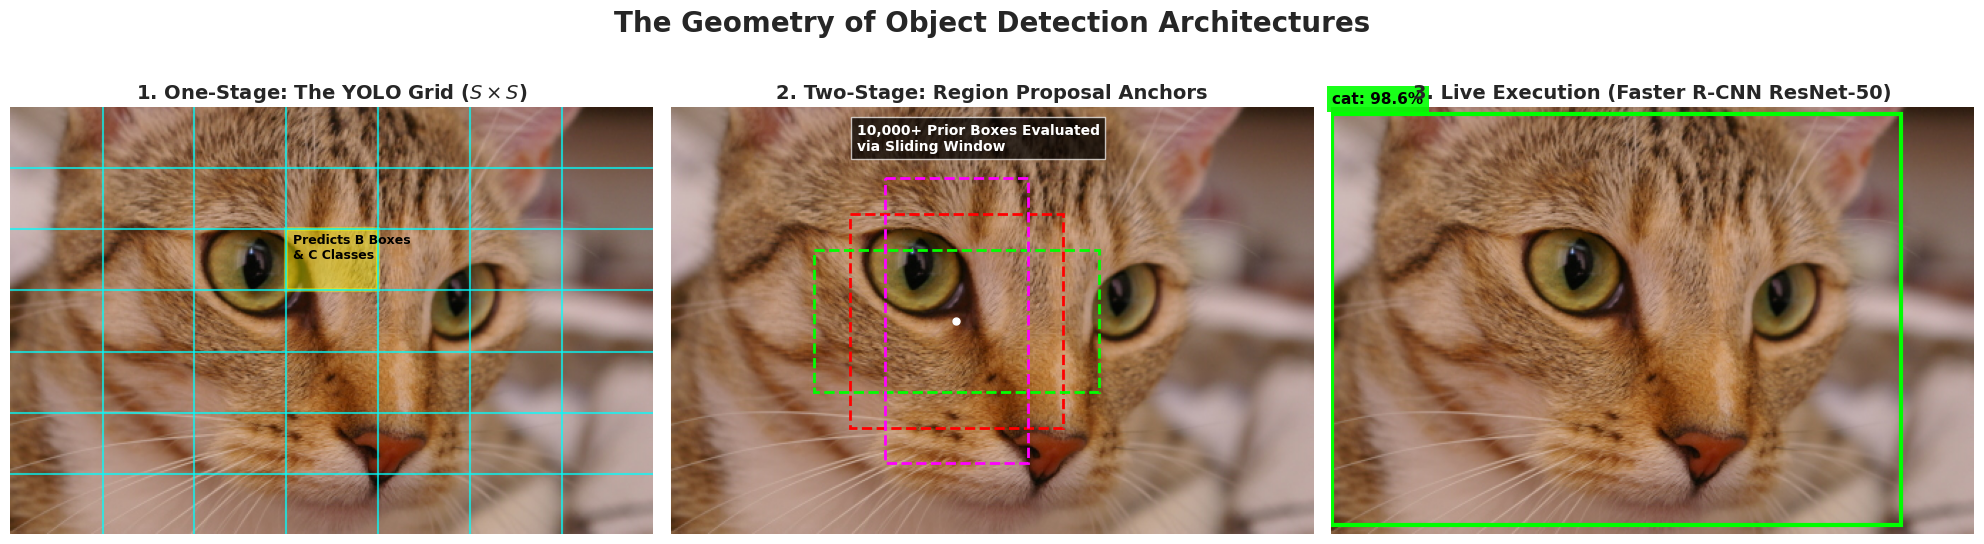


--- 💡 Engineering Insight ---
Look at Plot 3. The Faster R-CNN successfully located Chelsea. It generated thousands of anchor boxes (like in Plot 2), used the RPN to filter them down to areas of interest, extracted those specific pixel regions, passed them into a secondary dense network, and applied bounding-box regression to tightly wrap the box exactly around the cat's physical dimensions. All of this highly complex mathematical surgery happened in a fraction of a second.


In [2]:
# 1. Fetch the Target Image
numpy_cat = data.chelsea()

# 2. Setup the Visualization Canvas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("The Geometry of Object Detection Architectures", fontsize=20, fontweight='bold')

# --- Plot A: The YOLO Grid Concept ---
axes[0].imshow(numpy_cat)
axes[0].set_title("1. One-Stage: The YOLO Grid ($S \\times S$)", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Draw a simulated 7x7 Grid over the image
h, w, _ = numpy_cat.shape
cell_h, cell_w = h / 7, w / 7
for i in range(1, 7):
    axes[0].axhline(i * cell_h, color='cyan', linewidth=1.5, alpha=0.7)
    axes[0].axvline(i * cell_w, color='cyan', linewidth=1.5, alpha=0.7)

# Highlight a specific grid cell that contains the center of the cat's face
rect = patches.Rectangle((3 * cell_w, 2 * cell_h), cell_w, cell_h, linewidth=3, edgecolor='yellow', facecolor='yellow', alpha=0.4)
axes[0].add_patch(rect)
axes[0].text(3 * cell_w + 5, 2 * cell_h + 20, "Predicts B Boxes\n& C Classes", color='black', fontweight='bold', fontsize=9)

# --- Plot B: The Faster R-CNN Anchor Concept ---
axes[1].imshow(numpy_cat)
axes[1].set_title("2. Two-Stage: Region Proposal Anchors", fontweight='bold', fontsize=14)
axes[1].axis('off')

# Draw simulated overlapping anchors of different aspect ratios at a single feature point
center_x, center_y = 200, 150
anchors = [
    (150, 150, 'red'),    # Square 1:1
    (200, 100, 'lime'),   # Wide 2:1
    (100, 200, 'magenta') # Tall 1:2
]
for aw, ah, color in anchors:
    rect = patches.Rectangle((center_x - aw/2, center_y - ah/2), aw, ah, linewidth=2, edgecolor=color, facecolor='none', linestyle='--')
    axes[1].add_patch(rect)
axes[1].plot(center_x, center_y, 'o', color='white', markersize=5)
axes[1].text(center_x - 70, center_y - 120, "10,000+ Prior Boxes Evaluated\nvia Sliding Window", color='white', fontweight='bold', fontsize=10, bbox=dict(facecolor='black', alpha=0.7))


# --- Plot C: Executing a Live Faster R-CNN ---
axes[2].imshow(numpy_cat)
axes[2].set_title("3. Live Execution (Faster R-CNN ResNet-50)", fontweight='bold', fontsize=14)
axes[2].axis('off')

# 1. Download and Initialize the Pretrained Enterprise Architecture
print("--- 📥 Downloading Pretrained Faster R-CNN (ResNet-50 FPN) ---")
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = detection.fasterrcnn_resnet50_fpn(weights=weights, progress=False)
model.eval() # Set to evaluation mode!

# 2. Prepare the Image Tensor
transform = transforms.ToTensor()
cat_tensor = transform(numpy_cat).unsqueeze(0) # [1, 3, 300, 451]

# 3. Execute the Forward Pass
print("--- 🧠 Executing Two-Stage Forward Pass ---")
with torch.no_grad():
    # The model automatically runs the RPN, RoI Pooling, and NMS!
    predictions = model(cat_tensor)[0] 

# 4. Parse the Output Matrix
# The COCO dataset Class ID for 'Cat' is 17.
boxes = predictions['boxes']
labels = predictions['labels']
scores = predictions['scores']

# Filter out low-confidence predictions (e.g., < 80%)
CONFIDENCE_THRESHOLD = 0.80

print(f"Total Raw Regions Proposed by Network: {len(boxes)}")

for i in range(len(boxes)):
    if scores[i] >= CONFIDENCE_THRESHOLD:
        box = boxes[i].numpy()
        class_id = labels[i].item()
        score = scores[i].item()
        
        # Get the human-readable class name from the weights dictionary
        class_name = weights.meta["categories"][class_id]
        
        print(f"✅ Object Detected: {class_name} (Confidence: {score*100:.2f}%) at {box.round(1)}")
        
        # Draw the final predicted box
        rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1], 
                                 linewidth=3, edgecolor='lime', facecolor='none')
        axes[2].add_patch(rect)
        axes[2].text(box[0], box[1] - 8, f"{class_name}: {score*100:.1f}%", color='black', fontsize=11, 
                     fontweight='bold', bbox=dict(facecolor='lime', alpha=0.9, edgecolor='none'))

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at Plot 3. The Faster R-CNN successfully located Chelsea. It generated thousands of anchor boxes (like in Plot 2), used the RPN to filter them down to areas of interest, extracted those specific pixel regions, passed them into a secondary dense network, and applied bounding-box regression to tightly wrap the box exactly around the cat's physical dimensions. All of this highly complex mathematical surgery happened in a fraction of a second.")

## Real-World Use Case or Analogy:

Think of the difference between Two-Stage (R-CNN) and One-Stage (YOLO) detectors like **Two different strategies for finding Waldo in a giant Where's Waldo book**:

* **Faster R-CNN (The Two-Stage Detective)**:
* **Stage 1 (Region Proposal)**: You scan the entire page very quickly and draw circles around 50 different spots that look vaguely red-and-white striped. You don't know if it's Waldo, a candy cane, or a beach towel. You just circle them.
* **Stage 2 (Classification)**: You take a magnifying glass and look incredibly closely at *only* the 50 circled spots. You carefully analyze the stripes, the glasses, and the hat. You finally confirm Waldo.
* **Result**: Highly accurate. You will never mistake a candy cane for Waldo, but it takes you a long time to finish the page.


* **YOLO (The One-Stage Speed Reader)**:
* You take a clear plastic sheet with a massive $10 \times 10$ grid drawn on it and drop it over the page.
* You train your eyes to look at every single square on the grid simultaneously. In a split second, you mathematically process the entire page. For every single grid square, you instantly shout out, *"There is a 90% chance Waldo is in square 4-C, and he takes up exactly 10% of the square's area!"*
* **Result**: You processed the page in half a second. You might accidentally classify a tiny candy cane as Waldo (lower precision on small objects), but you can process 60 pages a minute, making it perfect for real-time robotic vision.